In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

penguins = sns.load_dataset('penguins')

print("--- Info ---")
penguins.info()
print("\n--- Describe ---")
print(penguins.describe())
print("\n--- Missing Values ---")
print(penguins.isnull().sum())

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB

--- Describe ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.0

In [2]:
penguins.dropna(inplace=True)
penguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


### Task 1

In [3]:
numeric_cols = penguins.select_dtypes(include=[np.number]).columns.tolist()
pairs = []
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        pairs.append((numeric_cols[i], numeric_cols[j]))

results = []
for p1, p2 in pairs:
    r, p_pearson = pearsonr(penguins[p1], penguins[p2])
    rho, p_spearman = spearmanr(penguins[p1], penguins[p2])
    results.append({
        'Pair': f"{p1} - {p2}",
        'Pearson r': round(r, 4),
        'Pearson p-val': f"{p_pearson:.4e}",
        'Spearman rho': round(rho, 4),
        'Spearman p-val': f"{p_spearman:.4e}"
    })

summary_df = pd.DataFrame(results)
summary_df

,Pair,Pearson r,Pearson p-val,Spearman rho,Spearman p-val
0,bill_length_mm - bill_depth_mm,-0.2286,2.5283e-05,-0.2139,8.3720e-05
1,bill_length_mm - flipper_length_mm,0.6531,7.2113e-42,0.6698,1.0737e-44
2,bill_length_mm - body_mass_g,0.5895,1.5386e-32,0.5765,6.9720e-31
3,bill_depth_mm - flipper_length_mm,-0.5778,4.7782e-31,-0.5173,3.4565e-24
4,bill_depth_mm - body_mass_g,-0.4720,7.0242e-20,-0.4293,2.3073e-16
5,flipper_length_mm - body_mass_g,0.8730,3.1328e-105,0.8404,4.6304e-90


### Task 1 Analysis
Strongest linear relationships: Flipper length and body mass show the strongest Pearson correlation.
Disagreement: Most pairs show similar values, but bill length and bill depth have relatively lower correlations. Disagreements usually occur when the relationship is non-linear or outliers are present.

### Task 2

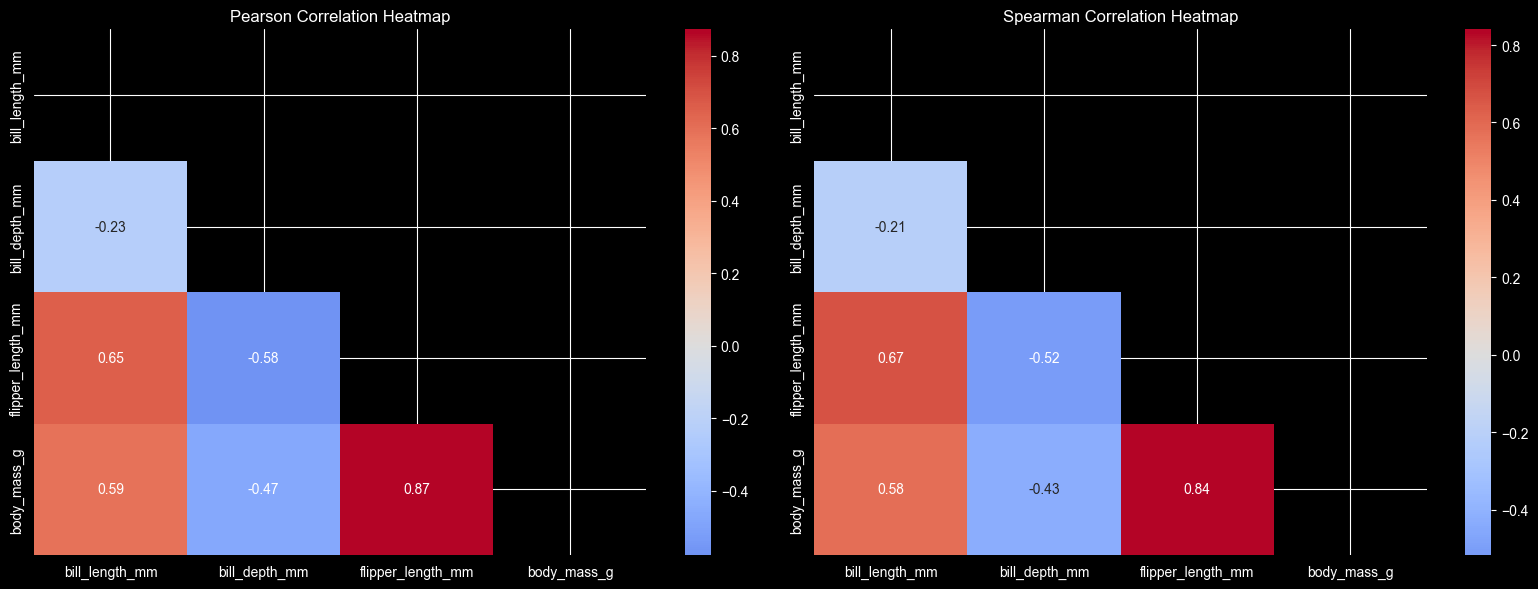

In [4]:
pearson_corr = penguins[numeric_cols].corr(method='pearson')
spearman_corr = penguins[numeric_cols].corr(method='spearman')

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, mask=mask, ax=ax[0])
ax[0].set_title('Pearson Correlation Heatmap')

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, mask=mask, ax=ax[1])
ax[1].set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

### Task 2 Analysis
Agreement: The heatmaps agree on the strong positive correlation between flipper length and body mass.
Difference: Spearman is slightly higher in some cases, suggesting monotonic but not perfectly linear relationships.

### Task 3

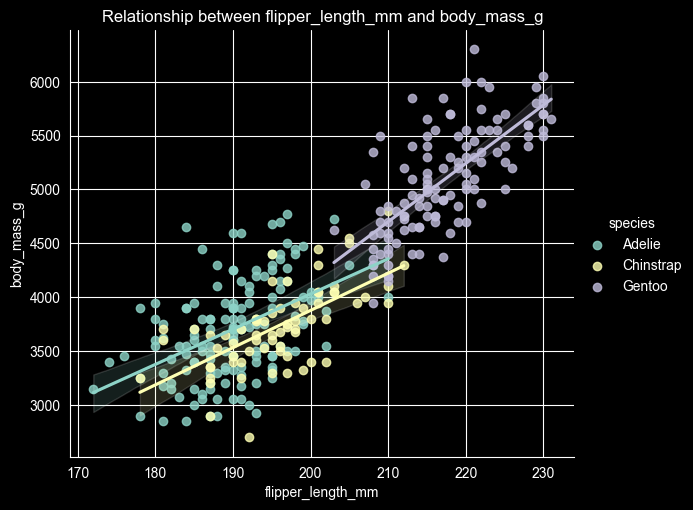

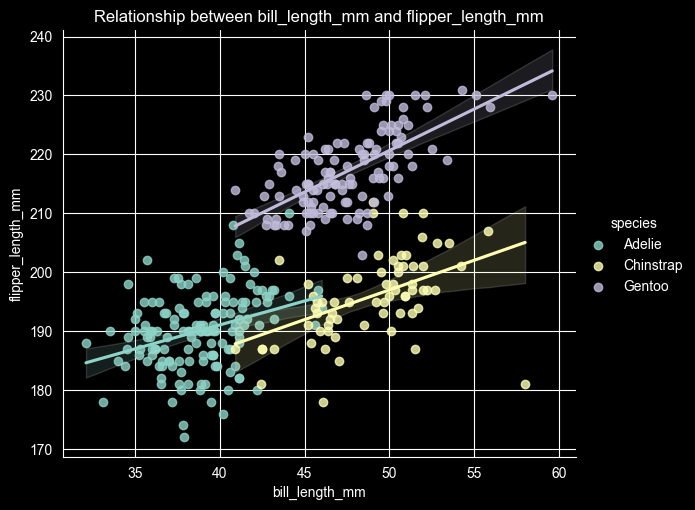

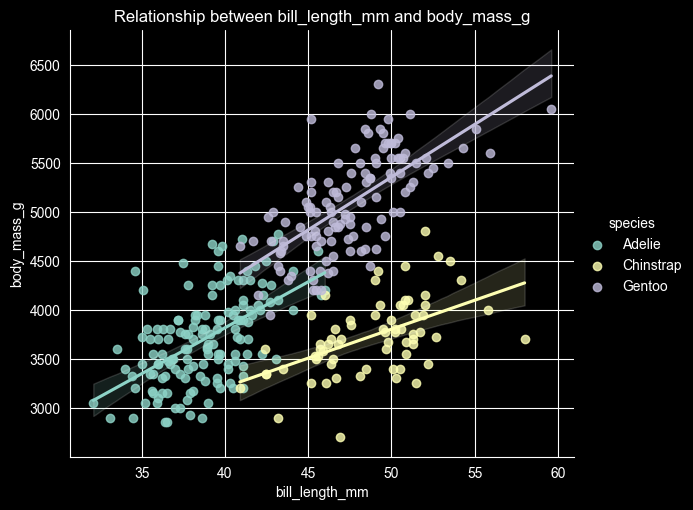

In [5]:
top_pairs = summary_df.iloc[summary_df['Pearson r'].abs().nlargest(3).index]

for idx, row in top_pairs.iterrows():
    p1, p2 = row['Pair'].split(' - ')
    sns.lmplot(data=penguins, x=p1, y=p2, hue='species', height=5, aspect=1.2)
    plt.title(f'Relationship between {p1} and {p2}')
    plt.show()

### Task 3 Analysis
Regression line performance: The regression lines capture the general trend within species well.
Subgroup effects: Different species often show distinct clusters. In some cases, like bill length vs depth (not top 3 but notable), Simpson's Paradox might be observed if analyzed further.